In [19]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "flow"))

from flow_helpers import *

C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

allpsrs = sorted(
    [ds.Pulsar.read_feather(psrfile) for psrfile in list(feathers.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True)


In [21]:
psrs = [allpsrs[0]] 
psr = psrs[0]
Tspan = ds.getspan(psrs)
rn_components = 30
powerlaw = ds.powerlaw

In [22]:
rn_params = {"log10_A": -12, "gamma": 5} # we can set this to whatever we like, the TtNT is independent of IRN choice

pslmodels_inj = [ds.PulsarLikelihood([psr.residuals,
                                          ds.makegp_timing(psr, svd=True),
                                          ds.makenoise_measurement(psr, noisedict=psr.noisedict),
                                          ds.makegp_fourier(psr, ds.partial(powerlaw, **rn_params),
                                                            rn_components, name='red_noise', T=Tspan)])]

        

In [23]:
psr_noisedicts = [psr.noisedict for psr in psrs]
L0s, ahat0_list, _ = compute_zero_quantities(pslmodels_inj, psr_noisedicts)
L0s = jnp.stack(L0s)
ahat0_list = jnp.stack(ahat0_list)
Sigma_0_inv = jax.vmap(lambda L0: jnp.linalg.inv(L0 @ L0.T))(L0s)

b0s = jax.vmap(lambda L0, ahat0: jsp.linalg.cho_solve((L0, True), ahat0))(L0s, ahat0_list)

_, f, df = construct_freqs(psrs, num_frequencies=rn_components)

TtNT, _ = TtNT_mpsrs(Sigma_0_inv, params_list=[rn_params] * 1,
                                f=f, df=df, powerlaw=powerlaw)

psrnames = [psr.name for psr in pslmodels_inj]
rn_amp_keys, rn_gamma_keys = create_rn_keys(psrnames)



In [24]:
plt.style.use("../matplotlib.mplstyle")

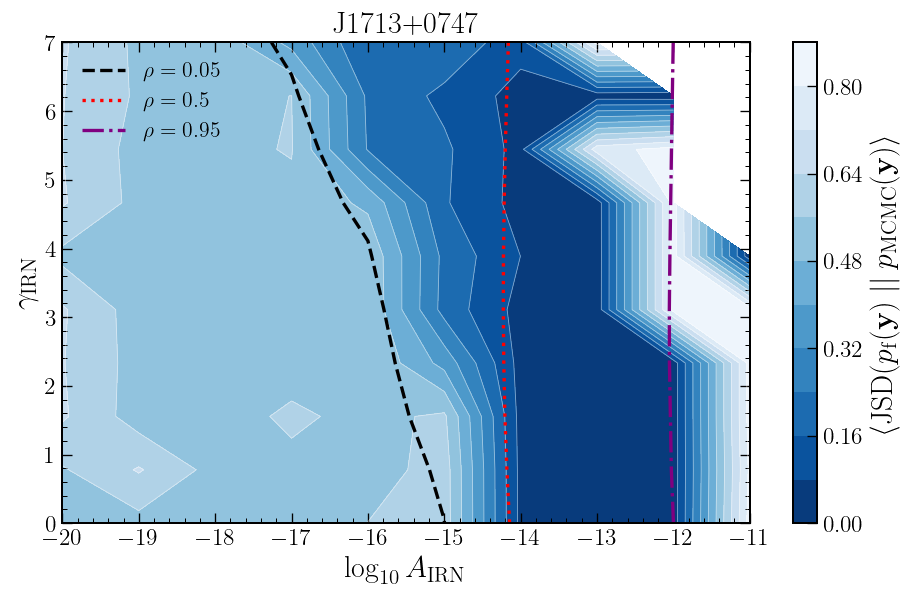

In [ ]:
import pandas as pd
df_results = pd.read_csv(f"js_sensitivity_grid.csv")

log10A_grid = np.linspace(-20, -11, 10)
gamma_grid  = np.linspace(0,  7, 10)

def sigma_phi_ratio(log10A_grid, gamma_grid, TtNT_i, f, df, powerlaw):
    grid = np.zeros((len(gamma_grid), len(log10A_grid)))
    
    for i, gamma in enumerate(gamma_grid):
        for j, log10_A in enumerate(log10A_grid):
            params = {'log10_A': log10_A, 'gamma': gamma}
            
            phi0_inv, _ = phi_sp(params, f, df, powerlaw)
            sigma_inv = TtNT_i + phi0_inv
            sigma = np.linalg.inv(sigma_inv)
            phi_diag = 1.0 / np.diag(phi0_inv)
            
            grid[i, j] = float(1.0 - np.mean(np.diag(sigma) / phi_diag))
    return grid

_, f, df = construct_freqs(psrs, num_frequencies=rn_components)
sigma_phi_grid = sigma_phi_ratio(log10A_grid, gamma_grid, 
                             np.array(TtNT[0]), f, df, powerlaw)

pivot = df_results.pivot(index='gamma', columns='log10_A', values='js_mean')

fig, ax = plt.subplots()
im = ax.contourf(log10A_grid, gamma_grid, pivot.values,
                 levels=10, cmap='Blues_r')
ax.contour(log10A_grid, gamma_grid, pivot.values,
           levels=10, colors='white', linewidths=0.5, alpha=0.5)

clrs = ['black', 'red', 'purple']
rhos = [0.05, 0.5, 0.95]
lss = linestyles=['--', ':', '-.']
ax.contour(log10A_grid, gamma_grid, sigma_phi_grid,
           levels=rhos, colors=clrs,
           linewidths=2.0, linestyles = lss)

labels = [rf'$\rho={r}$' for r in rhos]

# to get working labels
for level, color, label, ls in zip(rhos, clrs, labels,lss):
    ax.plot([], [], color=color, linestyle=ls, linewidth=2, label=label)
    
ax.set_xlabel(r'$\log_{10} A_\mathrm{IRN}$')
ax.set_ylabel(r'$\gamma_\mathrm{IRN}$')
plt.colorbar(im, ax=ax, label=r'$\langle \mathrm{JSD}(p_\mathrm{f}(\mathbf y) \mid \mid p_\mathrm{MCMC}(\mathbf y)\rangle$')

ax.legend(loc='upper left')
plt.tight_layout()
plt.title("J1713+0747")
#plt.savefig(r"J1713_scan.pdf")
plt.show()
